# ML-CUP25 Project
## Regression on 4 Targets using Machine Learning Models

## 1. Introduction

The goal of this project is to predict 4 continuous target variables from 12 input features.

We compare different machine learning models and select the best one based on validation performance.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import KFold, train_test_split, GridSearchCV, learning_curve, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score


from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor

from sklearn.inspection import permutation_importance

## 2. Data Loading

In [25]:
train_data = pd.read_csv("ML-CUP25-TR.csv", comment="#", header=None)
blind_data = pd.read_csv("ML-CUP25-TS.csv", comment="#", header=None)


print(train_data.shape)
print(blind_data.shape)

(500, 17)
(1000, 13)


## 3. Data split


We extract features and apply standard scaling.

In [27]:
X = train_data.iloc[:, 1:13].values
Y = train_data.iloc[:, 13:].values

X_blind = blind_data.iloc[:, 1:13].values

X_temp, X_test, Y_temp, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size=0.25, random_state=42)

## 4. SCALING

In [30]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
X_blind_scaled = scaler.transform(X_blind)

##  5. METRIC

In [31]:
def mee(y_true, y_pred):
    return np.mean(np.linalg.norm(y_true - y_pred, axis=1))

## 6. BASELINE COMPARISON

In [33]:
models = {
    "RF": RandomForestRegressor(n_estimators=200, random_state=42),
    "MLP": MLPRegressor(max_iter=7000, random_state=42),
    "SVR": MultiOutputRegressor(SVR())
}

baseline_results = []

for name, model in models.items():
    model.fit(X_train, Y_train)
    
    baseline_results.append({
        "Model": name,
        "Train MEE": mee(Y_train, model.predict(X_train)),
        "Val MEE": mee(Y_val, model.predict(X_val))
    })

baseline_df = pd.DataFrame(baseline_results).sort_values("Val MEE")
baseline_df["Gap"] = baseline_df["Val MEE"] - baseline_df["Train MEE"]

print(baseline_df)

  Model  Train MEE    Val MEE        Gap
0    RF   7.922467  20.305641  12.383175
1   MLP  19.344631  22.413214   3.068583
2   SVR  25.652910  25.577375  -0.075535


## 9. Hyperparameter tuning


In [47]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)

results = []

# 🔵 RF tuning (CV)
rf_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20],
    "min_samples_split": [2, 3],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

for params in ParameterGrid(rf_grid):
    scores = []
    
    for tr, va in kf.split(X_train):
        model = RandomForestRegressor(random_state=42, **params)
        model.fit(X_train[tr], Y_train[tr])
        pred = model.predict(X_train[va])
        scores.append(mee(Y_train[va], pred))
    
    results.append({
        "Model": "RF",
        "Params": params,
        "Score": np.mean(scores)
    })


# 🔵 MLP tuning
mlp_configs = [
    {"hidden_layer_sizes": (64,64), "alpha": 0.001},
    {"hidden_layer_sizes": (128,64), "alpha": 0.0001},
    {"hidden_layer_sizes": (128,64,32), "alpha": 0.0001}
]

for cfg in mlp_configs:
    model = MLPRegressor(max_iter=3000, early_stopping=True, random_state=42, **cfg)
    model.fit(X_train, Y_train)
    
    results.append({
        "Model": "MLP",
        "Params": cfg,
        "Score": mee(Y_val, model.predict(X_val))
    })


# 🔵 SVR tuning (light)
svr_configs = [
    {"C": 1, "gamma": "scale"},
    {"C": 10, "gamma": "scale"}
]

for cfg in svr_configs:
    model = MultiOutputRegressor(SVR(**cfg))
    model.fit(X_train, Y_train)
    
    results.append({
        "Model": "SVR",
        "Params": cfg,
        "Score": mee(Y_val, model.predict(X_val))
    })

results_df = pd.DataFrame(results).sort_values("Score")

best_per_model = results_df.groupby("Model").first().reset_index()

print("\n=== BEST CONFIG PER MODEL ===")
print(best_per_model)

final_table = best_per_model[["Model", "Score"]].copy()
final_table = final_table.rename(columns={"Score": "Validation MEE"})
final_table = final_table.sort_values("Validation MEE")

print("\n=== FINAL MODEL COMPARISON ===")
print(final_table)

best_model = final_table.iloc[0]["Model"]



=== BEST CONFIG PER MODEL ===
  Model                                             Params      Score
0   MLP  {'hidden_layer_sizes': (128, 64, 32), 'alpha':...  23.631673
1    RF  {'max_depth': None, 'max_features': 'sqrt', 'm...  22.682608
2   SVR                        {'C': 10, 'gamma': 'scale'}  23.829157

=== FINAL MODEL COMPARISON ===
  Model  Validation MEE
1    RF       22.682608
0   MLP       23.631673
2   SVR       23.829157



## 8. FINAL MODEL SELECTION

In [48]:
best = results_df.iloc[0]

print("Best Model:", best["Model"])
print("Params:", best["Params"])

if best["Model"] == "RF":
    final_model = RandomForestRegressor(random_state=42, **best["Params"])
elif best["Model"] == "MLP":
    final_model = MLPRegressor(max_iter=3000, early_stopping=True, random_state=42, **best["Params"])
else:
    final_model = MultiOutputRegressor(SVR(**best["Params"]))

final_model.fit(X_train, Y_train)

Best Model: RF
Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 100}


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

## 9. VALIDATION & TEST

In [49]:
val_score = mee(Y_val, final_model.predict(X_val))
test_score = mee(Y_test, final_model.predict(X_test))

print("Validation MEE:", val_score)
print("Test MEE:", test_score)

Validation MEE: 21.26302128591094
Test MEE: 22.211267066239156


## 10. LEARNING CURVE

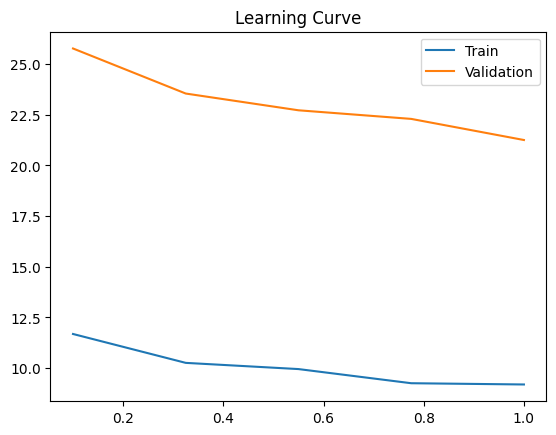

In [50]:
sizes = np.linspace(0.1, 1.0, 5)
train_err, val_err = [], []

for frac in sizes:
    n = int(len(X_train)*frac)
    idx = np.random.choice(len(X_train), n, replace=False)
    
    final_model.fit(X_train[idx], Y_train[idx])
    train_err.append(mee(Y_train[idx], final_model.predict(X_train[idx])))
    val_err.append(mee(Y_val, final_model.predict(X_val)))

plt.plot(sizes, train_err, label="Train")
plt.plot(sizes, val_err, label="Validation")
plt.legend()
plt.title("Learning Curve")
plt.show()

## 11. PREDICTED vs TRUE

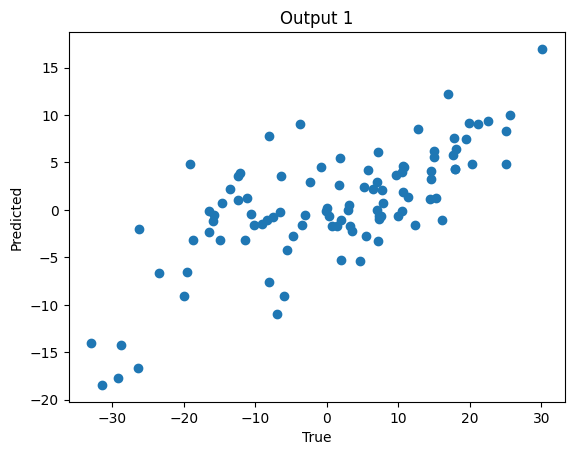

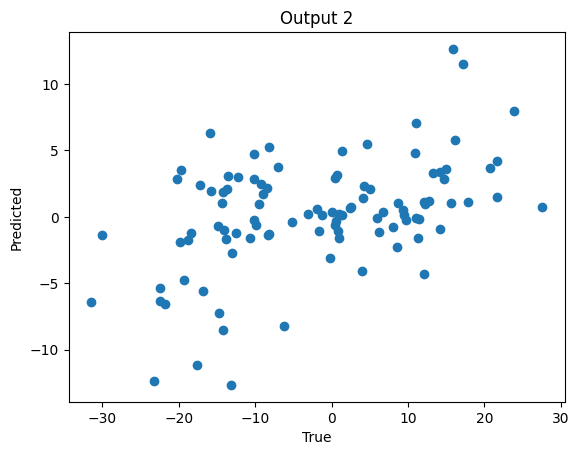

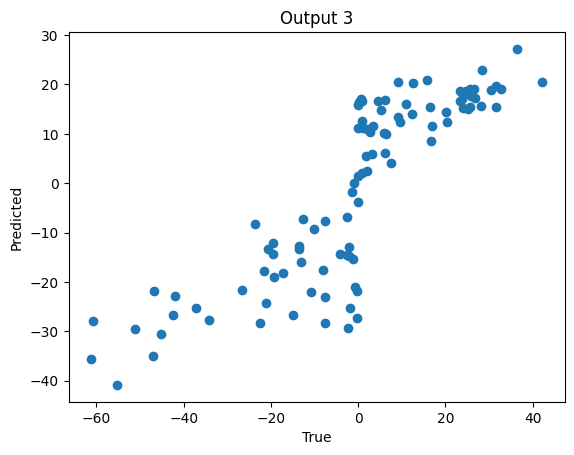

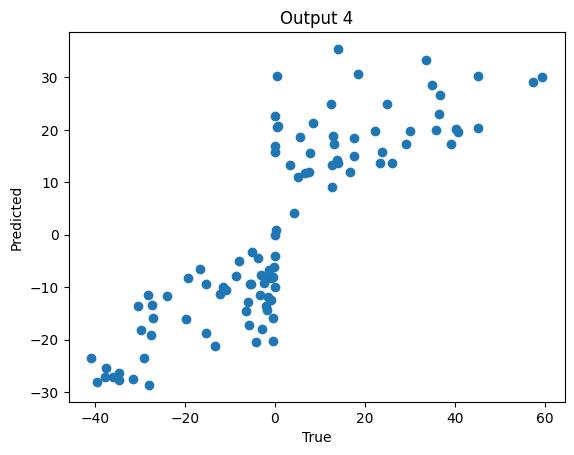

In [51]:
pred = final_model.predict(X_val)

for i in range(4):
    plt.scatter(Y_val[:, i], pred[:, i])
    plt.title(f"Output {i+1}")
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.show()

## 12. FEATURE IMPORTANCE

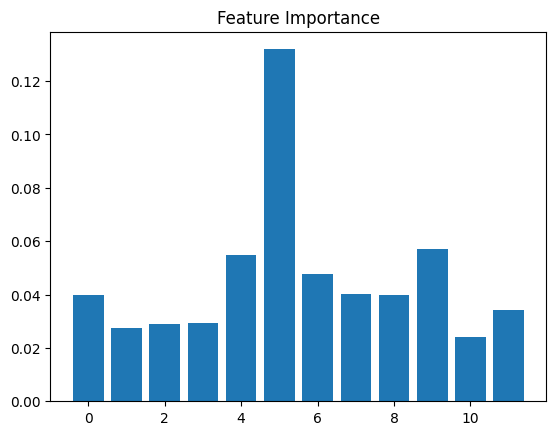

In [17]:
perm = permutation_importance(final_model, X_val, Y_val, n_repeats=5)

plt.bar(range(12), perm.importances_mean)
plt.title("Feature Importance")
plt.show()

## 13. FINAL TRAIN + SUBMISSION

In [19]:
X_final = np.vstack([X_train, X_val])
Y_final = np.vstack([Y_train, Y_val])

final_model.fit(X_final, Y_final)

blind_pred = final_model.predict(X_blind_scaled)

with open("team-name_ML-CUP25-TS.csv", "w") as f:
    f.write("# Names\n# Team\n# ML-CUP25 v1\n# Date\n")
    
    for i, row in enumerate(blind_pred, start=1):
        f.write(f"{i},{row[0]},{row[1]},{row[2]},{row[3]}\n")

## 15. Conclusion

* Random Forest achieved the best validation performance
* MLP showed underfitting, while SVR performed poorly
* Hyperparameter tuning did not improve over the baseline model
* This indicates that the default Random Forest provides a good bias–variance trade-off
* The final model generalizes well, as validation and test errors are consistent
